In [1]:
# read BTCUSDT_5m.csv and create a dataframe with all the columns and shwow the first 5 rows
import pandas as pd
import numpy as np

df = pd.read_csv("/home/ayoub/Documents/projects/dec25_bde_int_crypto/data/raw_data/BTCUSDT_5m.csv")
print(df.head())

    open_time_ms      open      high       low     close    volume  \
0  1735689600000  93576.00  93702.15  93537.50  93661.20  45.94160   
1  1735689900000  93661.20  93678.02  93600.00  93607.10  71.94585   
2  1735690200000  93607.10  93656.19  93489.03  93656.18  57.96928   
3  1735690500000  93656.19  93840.05  93614.95  93796.35  39.74456   
4  1735690800000  93796.35  93898.05  93707.81  93740.00  38.38053   

   close_time_ms  quote_volume  trade_count  taker_buy_base_volume  \
0  1735689899999  4.301907e+06         7448               16.87967   
1  1735690199999  6.736121e+06         4165               16.66761   
2  1735690499999  5.423766e+06         8175               29.65936   
3  1735690799999  3.727084e+06         8031               18.83666   
4  1735691099999  3.600685e+06        10064               23.35948   

   taker_buy_quote_volume  ignore  
0            1.580504e+06       0  
1            1.560680e+06       0  
2            2.774717e+06       0  
3            1

In [2]:
# show type of each column
print(df.dtypes)

open_time_ms                int64
open                      float64
high                      float64
low                       float64
close                     float64
volume                    float64
close_time_ms               int64
quote_volume              float64
trade_count                 int64
taker_buy_base_volume     float64
taker_buy_quote_volume    float64
ignore                      int64
dtype: object


In [3]:
# convert open_time_ms and close_time_ms to datetime and show the first 5 rows of all the columns
df["open_time_ms"] = pd.to_datetime(df["open_time_ms"], unit="ms")
df["close_time_ms"] = pd.to_datetime(df["close_time_ms"], unit="ms")
print(df.head())

         open_time_ms      open      high       low     close    volume  \
0 2025-01-01 00:00:00  93576.00  93702.15  93537.50  93661.20  45.94160   
1 2025-01-01 00:05:00  93661.20  93678.02  93600.00  93607.10  71.94585   
2 2025-01-01 00:10:00  93607.10  93656.19  93489.03  93656.18  57.96928   
3 2025-01-01 00:15:00  93656.19  93840.05  93614.95  93796.35  39.74456   
4 2025-01-01 00:20:00  93796.35  93898.05  93707.81  93740.00  38.38053   

            close_time_ms  quote_volume  trade_count  taker_buy_base_volume  \
0 2025-01-01 00:04:59.999  4.301907e+06         7448               16.87967   
1 2025-01-01 00:09:59.999  6.736121e+06         4165               16.66761   
2 2025-01-01 00:14:59.999  5.423766e+06         8175               29.65936   
3 2025-01-01 00:19:59.999  3.727084e+06         8031               18.83666   
4 2025-01-01 00:24:59.999  3.600685e+06        10064               23.35948   

   taker_buy_quote_volume  ignore  
0            1.580504e+06       0  
1 

In [4]:
# delete ignore columns and show the first 5 rows of all the columns
df = df.drop(columns=["ignore"])
print(df.head())

         open_time_ms      open      high       low     close    volume  \
0 2025-01-01 00:00:00  93576.00  93702.15  93537.50  93661.20  45.94160   
1 2025-01-01 00:05:00  93661.20  93678.02  93600.00  93607.10  71.94585   
2 2025-01-01 00:10:00  93607.10  93656.19  93489.03  93656.18  57.96928   
3 2025-01-01 00:15:00  93656.19  93840.05  93614.95  93796.35  39.74456   
4 2025-01-01 00:20:00  93796.35  93898.05  93707.81  93740.00  38.38053   

            close_time_ms  quote_volume  trade_count  taker_buy_base_volume  \
0 2025-01-01 00:04:59.999  4.301907e+06         7448               16.87967   
1 2025-01-01 00:09:59.999  6.736121e+06         4165               16.66761   
2 2025-01-01 00:14:59.999  5.423766e+06         8175               29.65936   
3 2025-01-01 00:19:59.999  3.727084e+06         8031               18.83666   
4 2025-01-01 00:24:59.999  3.600685e+06        10064               23.35948   

   taker_buy_quote_volume  
0            1.580504e+06  
1            1.560

In [5]:
# check the number of nan and empty values in each column
print(df.isna().sum())
print(df.isnull().sum())    

open_time_ms              0
open                      0
high                      0
low                       0
close                     0
volume                    0
close_time_ms             0
quote_volume              0
trade_count               0
taker_buy_base_volume     0
taker_buy_quote_volume    0
dtype: int64
open_time_ms              0
open                      0
high                      0
low                       0
close                     0
volume                    0
close_time_ms             0
quote_volume              0
trade_count               0
taker_buy_base_volume     0
taker_buy_quote_volume    0
dtype: int64


In [6]:
# show type of each column
print(df.dtypes)

open_time_ms              datetime64[ms]
open                             float64
high                             float64
low                              float64
close                            float64
volume                           float64
close_time_ms             datetime64[ms]
quote_volume                     float64
trade_count                        int64
taker_buy_base_volume            float64
taker_buy_quote_volume           float64
dtype: object


In [7]:
# create a new column called target which is the difference between close and open price If the closing price of the next candle ($t+1$) is higher than the current price ($t$), then the target is 1 (Buy). Otherwise, it is 0 (Sell).
df["target"] = (df["close"].shift(-1) > df["open"]).astype(int)
print(df.head())

         open_time_ms      open      high       low     close    volume  \
0 2025-01-01 00:00:00  93576.00  93702.15  93537.50  93661.20  45.94160   
1 2025-01-01 00:05:00  93661.20  93678.02  93600.00  93607.10  71.94585   
2 2025-01-01 00:10:00  93607.10  93656.19  93489.03  93656.18  57.96928   
3 2025-01-01 00:15:00  93656.19  93840.05  93614.95  93796.35  39.74456   
4 2025-01-01 00:20:00  93796.35  93898.05  93707.81  93740.00  38.38053   

            close_time_ms  quote_volume  trade_count  taker_buy_base_volume  \
0 2025-01-01 00:04:59.999  4.301907e+06         7448               16.87967   
1 2025-01-01 00:09:59.999  6.736121e+06         4165               16.66761   
2 2025-01-01 00:14:59.999  5.423766e+06         8175               29.65936   
3 2025-01-01 00:19:59.999  3.727084e+06         8031               18.83666   
4 2025-01-01 00:24:59.999  3.600685e+06        10064               23.35948   

   taker_buy_quote_volume  target  
0            1.580504e+06       1  
1 

In [8]:
# Feature Engineering

df["return"] = df["close"].pct_change()
df["log_return"] = np.log(df["close"] / df["close"].shift(1))
df["volatility"] = df["return"].rolling(12).std()
df["ma_10"] = df["close"].rolling(10).mean()
df["ma_30"] = df["close"].rolling(30).mean()
df["momentum"] = df["close"] - df["close"].shift(10)
df["buy_ratio"] = df["taker_buy_base_volume"] / df["volume"]
df["spread"] = df["high"] - df["low"]

df = df.dropna()

In [9]:
# sort the dataframe by open_time_ms and show the first 5 rows
df = df.sort_values(by="open_time_ms")
print(df.head())

          open_time_ms      open      high       low     close    volume  \
29 2025-01-01 02:25:00  93716.81  93742.52  93702.62  93742.52  11.93177   
30 2025-01-01 02:30:00  93742.51  93799.36  93742.51  93773.61  13.91987   
31 2025-01-01 02:35:00  93773.61  93880.00  93773.60  93879.99  12.32596   
32 2025-01-01 02:40:00  93879.99  93921.86  93855.17  93921.86  13.58807   
33 2025-01-01 02:45:00  93921.86  93965.20  93912.00  93934.22  10.69693   

             close_time_ms  quote_volume  trade_count  taker_buy_base_volume  \
29 2025-01-01 02:29:59.999  1.118177e+06         1347                7.75213   
30 2025-01-01 02:34:59.999  1.305277e+06         3804                8.56202   
31 2025-01-01 02:39:59.999  1.156602e+06         3743                8.29096   
32 2025-01-01 02:44:59.999  1.275904e+06         2972                9.99580   
33 2025-01-01 02:49:59.999  1.004897e+06         3873                6.68824   

    taker_buy_quote_volume  target    return  log_return  vola

In [10]:
# split the dataframe into train and test sets
train_size = int(len(df) * 0.8)
train = df[:train_size]
test = df[train_size:]

In [11]:
# normalize anti data leakage
from sklearn.preprocessing import StandardScaler

features = [
    "log_return","volatility","ma_10","ma_30",
    "momentum","buy_ratio","spread","trade_count"
]

scaler = StandardScaler()

X_train = scaler.fit_transform(train[features])
X_test = scaler.transform(test[features])
y_train = train["target"]
y_test = test["target"]

In [12]:
# Logistic Regression Model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [13]:
# evaluate the model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))
# calculate the accuracy score
print("Accuracy:", accuracy_score(y_test, predictions))

print("============")

# calculate accuracy train and test
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
print("Train Score:", train_score)
print("Test Score:", test_score)


              precision    recall  f1-score   support

           0       0.74      0.74      0.74     12204
           1       0.74      0.74      0.74     12247

    accuracy                           0.74     24451
   macro avg       0.74      0.74      0.74     24451
weighted avg       0.74      0.74      0.74     24451

[[9054 3150]
 [3123 9124]]
Accuracy: 0.7434460758251197
Train Score: 0.7488088178155866
Test Score: 0.7434460758251197


AUC Score: 0.8172561848804396


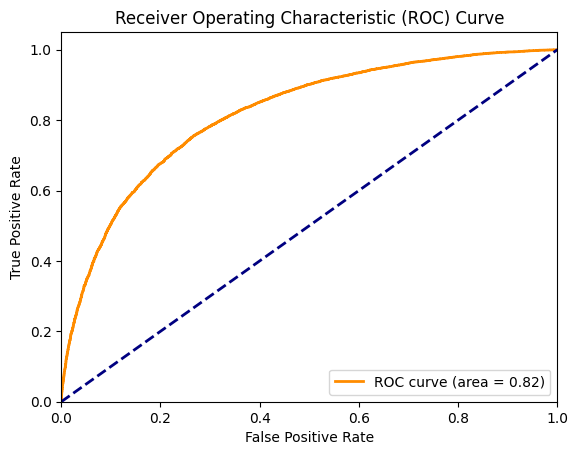

In [14]:
# create a roc curve and calculate the auc score
from sklearn.metrics import roc_curve, auc
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
print("AUC Score:", roc_auc)
# roc curve graph
import matplotlib.pyplot as plt
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [15]:
# save the model
import joblib
joblib.dump(model, "logistic_regression_model.pkl") 
joblib.dump(scaler, "logistic_regression_scaler.pkl")

['logistic_regression_scaler.pkl']